<a href="https://colab.research.google.com/github/mars8577/CSC.htm/blob/main/Linear_Regression.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
arr = [1, -4, 7, 12]
# iterate through each number
sum_var = 0
for num in arr:
  # check if each number is positive
  if num > 0:
    # if the number is positive - add that number to a variable
    sum_var += num
print(f'Total Sum: {sum_var}')

Total Sum: 20


In [ ]:
%%timeit
sum_var = 0
for num in arr:
  print(num)
  if num > 0:
    sum_var += num
    print(num)
    print(sum_var)
sum_var

Streaming output truncated to the last 5000 lines.
1
1
-4
7
7
8
12
12
20
1
1
1
-4
7
7
8
12
12
20
1
1
1
-4
7
7
8
12
12
20
1
1
1
-4
7
7
8
12
12
20
1
1
1
-4
7
7
8
12
12
20
1
1
1
-4
7
7
8
12
12
20
1
1
1
-4
7
7
8
12
12
20
1
1
1
-4
7
7
8
12
12
20
1
1
1
-4
7
7
8
12
12
20
1
1
1
-4
7
7
8
12
12
20
1
1
1
-4
7
7
8
12
12
20
1
1
1
-4
7
7
8
12
12
20
1
1
1
-4
7
7
8
12
12
20
1
1
1
-4
7
7
8
12
12
20
1
1
1
-4
7
7
8
12
12
20
1
1
1
-4
7
7
8
12
12
20
1
1
1
-4
7
7
8
12
12
20
1
1
1
-4
7
7
8
12
12
20
1
1
1
-4
7
7
8
12
12
20
1
1
1
-4
7
7
8
12
12
20
1
1
1
-4
7
7
8
12
12
20
1
1
1
-4
7
7
8
12
12
20
1
1
1
-4
7
7
8
12
12
20
1
1
1
-4
7
7
8
12
12
20
1
1
1
-4
7
7
8
12
12
20
1
1
1
-4
7
7
8
12
12
20
1
1
1
-4
7
7
8
12
12
20
1
1
1
-4
7
7
8
12
12
20
1
1
1
-4
7
7
8
12
12
20
1
1
1
-4
7
7
8
12
12
20
1
1
1
-4
7
7
8
12
12
20
1
1
1
-4
7
7
8
12
12
20
1
1
1
-4
7
7
8
12
12
20
1
1
1
-4
7
7
8
12
12
20
1
1
1
-4
7
7
8
12
12
20
1
1
1
-4
7
7
8
12
12
20
1
1
1
-4
7
7
8
12
12
20
1
1
1
-4
7
7
8
12
12
20
1
1
1
-4
7
7
8
12
12
20
1
1
1
-4
7
7
8


In [ ]:
%%timeit
sum([num for num in arr if num > 0])

179 ns ± 15.1 ns per loop (mean ± std. dev. of 7 runs, 10000000 loops each)


In [ ]:
# You get an array of numbers, return the sum of all of the positives ones.
def positive_sum(arr):
    # Your code here
    # iterate through each number
    sum_var = 0
    for num in arr:
      # check if each number is positive
      if num > 0:
        # if the number is positive - add that number to a variable
        sum_var += num
    return sum_var

In [ ]:
assert positive_sum([1, -4, 7, 12]) == 20

In [ ]:
assert positive_sum([9, -9, -1, 15]) == 24

In [ ]:
assert positive_sum([]) == 0

# Regression & Predictive Modeling

## Duration

## Agenda
1. **Conceptual Foundations**
   - What is regression?
   - Linear regression equation
   - Assumptions of regression

2. **Hands-On Coding**
   - Build a simple regression model
   - Evaluate with metrics (R², MAE, RMSE)
   - Visualize predictions

3. **Diagnostics & Assumptions**
   - Residual plots
   - Normality checks
   - Multicollinearity

4. **Practice & Wrap-Up**
   - Exercises
   - Quiz & discussion
   - Key takeaways


## 1. Conceptual Foundations

Linear regression models the relationship between a dependent variable (target) and one or more independent variables (features).

Equation:


$y = \beta_0 + \beta_1 x + \epsilon$



**Assumptions:**
1. Linearity  
2. Independence  
3. Homoscedasticity  
4. Normality of errors  
5. No multicollinearity

# Assumptions of Linear Regression

## Linearity
- The relationship between predictors (independent variables) and the target (dependent variable) is linear.
- Example: As advertising spend increases, sales increase in a straight-line fashion.

---

## Independence
- Observations are independent of each other.
- No hidden relationships between data points (e.g., repeated measures on the same subject without accounting for it).

---

## Homoscedasticity
- The variance of residuals (errors) is constant across all levels of the independent variables.
- Residuals should not "fan out" or "narrow" as predictions change.

---

## Normality of Errors
- Residuals (differences between actual and predicted values) should follow a normal distribution.
- Important for hypothesis testing and confidence intervals.

---

## No Multicollinearity
- Predictors should not be highly correlated with each other.
- High correlation between features makes it difficult to isolate their individual effects on the target.



In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
from sklearn.model_selection import train_test_split

# Synthetic dataset
np.random.seed(42)
X = np.random.rand(1000) * 10
y = 2.5 * X.flatten() + 5 + np.random.randn(1000) * 2

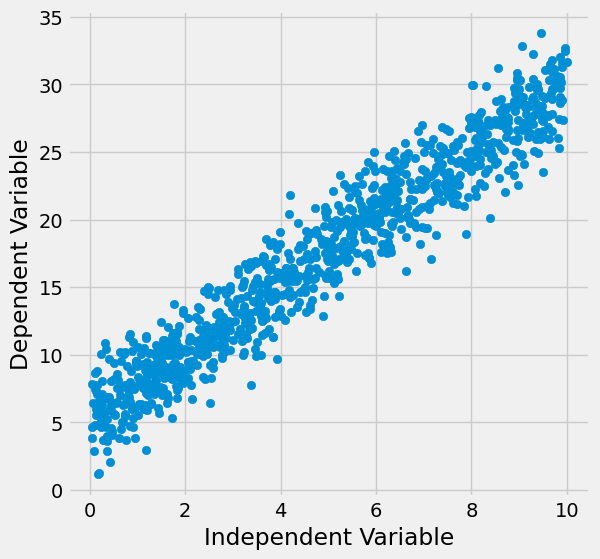

In [ ]:
# plot out our data

plt.style.use('fivethirtyeight')
plt.figure(figsize=(6, 6))
plt.scatter(X, y)
plt.xlabel('Independent Variable')
plt.ylabel('Dependent Variable');

In [ ]:
X.shape

(100,)

In [ ]:
pd.DataFrame({'X': X,
              'y': y}).corr()

,X,y
X,1.000000,0.969684
y,0.969684,1.000000


In [ ]:
# split into a training dataset and test dataset
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42)

X_train.shape, X_test.shape, y_train.shape, y_test.shape

((750,), (250,), (750,), (250,))

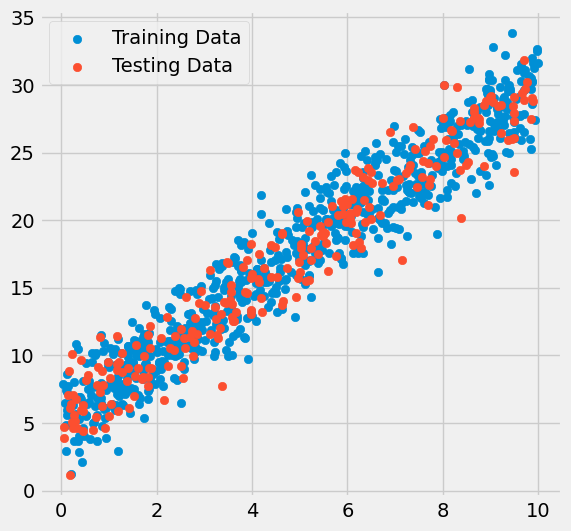

In [ ]:
plt.figure(figsize=(6, 6))
plt.scatter(X_train, y_train, label='Training Data')
plt.scatter(X_test, y_test, label='Testing Data')
plt.legend();

In [ ]:
X_train.shape, X_train.reshape(-1, 1).shape

((75,), (75, 1))

In [ ]:
X_train[:5]

array([1.8340451 , 1.22038235, 5.22732829, 7.08072578, 0.05522117])

In [ ]:
X_train.reshape(-1, 1)[:5]

array([[1.8340451 ],
       [1.22038235],
       [5.22732829],
       [7.08072578],
       [0.05522117]])

In [ ]:
# Make an instance of our Linear Regression model
lr = LinearRegression()

# fit our model
lr.fit(X_train.reshape(-1, 1), y_train)

LinearRegression()

In [ ]:
# get predictions on our test data
y_pred = lr.predict(X_test.reshape(-1, 1))

In [ ]:
# first 5 predictions
y_pred[:5]

array([ 6.85684282, 26.72707461, 23.79692287, 21.17417235, 11.52332149])

In [ ]:
# first 5 actual test values
y_test[:5]

array([ 7.90206597, 26.36373245, 21.83221781, 19.7442822 , 13.05156343])

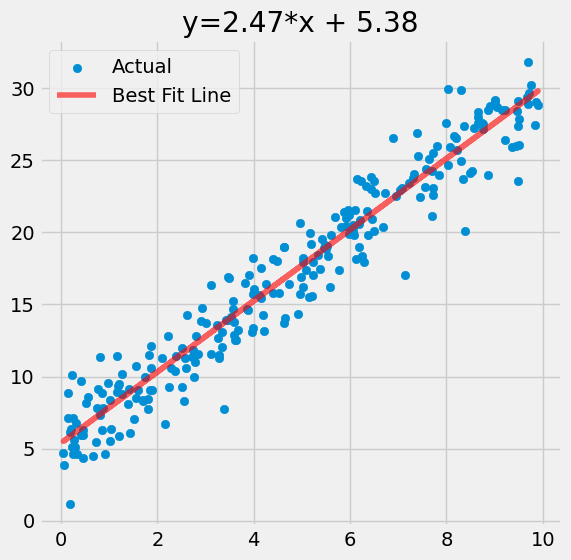

In [ ]:
plt.figure(figsize=(6, 6))
plt.scatter(X_test, y_test, label='Actual')
plt.plot(X_test, y_pred, label='Best Fit Line', color='red', alpha=0.6)
plt.title(f'y={round(lr.coef_[0], 2)}*x + {round(lr.intercept_, 2)}')
plt.legend();

In [ ]:
f'y={round(lr.coef_[0], 2)}*x + {round(lr.intercept_, 2)}'

'y=2.39*x + 5.34'

In [ ]:
lr.coef_, lr.intercept_

(array([2.39034919]), np.float64(5.33757630815745))

In [ ]:
# make a dataframe with my actual values and my predicted values

pred_df = pd.DataFrame({'actual': y_test,
                        'predicted': y_pred})

# step 1 calculate residual
pred_df['residual'] = pred_df['actual'] - pred_df['predicted']

# step 2 absolute value of the residual
pred_df['absolute_value_residual'] = np.abs(pred_df['residual'])

# step 3 take mean of absolute value of the residuals
print(f'Mean Absolute Error {pred_df['absolute_value_residual'].mean()}')

Mean Absolute Error 1.4322370204572117


In [ ]:
mean_absolute_error(y_test, y_pred)

1.4322370204572117

In [ ]:
y_test_corr = pd.DataFrame({'y_test': y_test,
                            'X_test': X_test})
y_test_corr.corr().loc['y_test', 'X_test'] ** 2

np.float64(0.9383757770873951)

In [ ]:
r2_score(y_test, y_pred)

0.9381162505847244

In [ ]:
# calculate R^2
lr.score(X_test.reshape(-1, 1), y_test)

0.9381162505847244

In [ ]:
# calculate R^2 on the training data
lr.score(X_train.reshape(-1, 1), y_train)

0.9274388135854583

In [ ]:
mean_squared_error(y_test, y_pred)

3.379131375212131

# Model Evaluation Metrics

## R² (Coefficient of Determination)
- Measures how well the regression model explains the variance in the data.
- Range: 0 to 1 (higher is better).
- Example: R² = 0.85 → 85% of the variance in the target is explained by the model.

---

## MAE (Mean Absolute Error)
- Average of the absolute differences between predicted and actual values.
- Easy to interpret: "On average, predictions are off by X units."
- Less sensitive to large errors compared to MSE.

---

## MSE (Mean Squared Error)
- Average of the squared differences between predicted and actual values.
- Penalizes larger errors more heavily (because of squaring).
- Useful when large errors are especially undesirable.

---

## Summary
- **R²** → How much variance is explained.  
- **MAE** → Average size of errors (absolute).  
- **MSE** → Average squared error, emphasizes large mistakes.  


## Diagnostics & Assumptions

### Residual Analysis
Residuals = Actual - Predicted

- Plot residuals vs. fitted values → check homoscedasticity
- Histogram or Q-Q plot of residuals → check normality


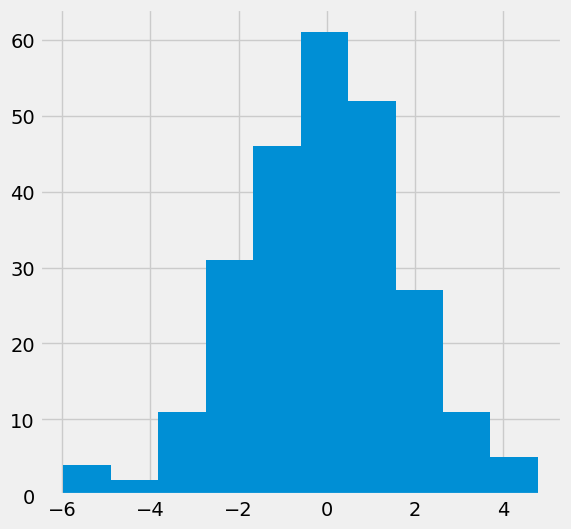

In [ ]:
residuals = y_test - y_pred

plt.figure(figsize=(6, 6))
plt.hist(residuals, bins=10);

In [ ]:
pred_df[pred_df['residual'] < -5]

,actual,predicted,residual,absolute_value_residual
10,20.129751,26.090411,-5.960660,5.960660
143,7.752794,13.725285,-5.972491,5.972491
149,17.072387,23.021929,-5.949541,5.949541
233,23.555931,28.821203,-5.265272,5.265272


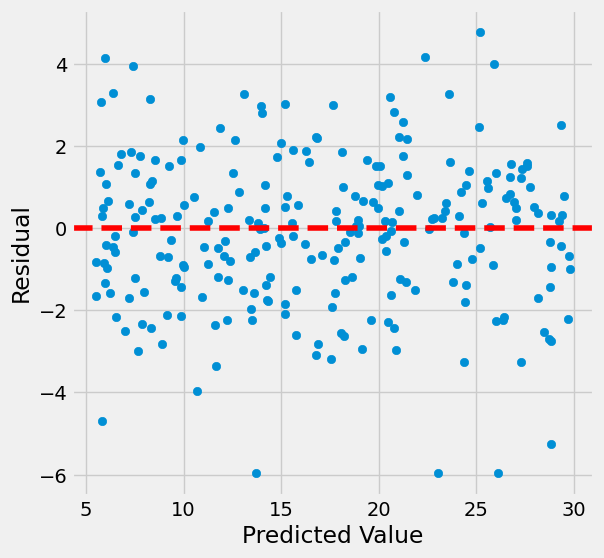

In [ ]:
plt.figure(figsize=(6, 6))
plt.scatter(y_pred, residuals)
plt.axhline(0, color='red', linestyle='--')
plt.xlabel('Predicted Value')
plt.ylabel('Residual');

In [ ]:
df = pd.read_csv('https://raw.githubusercontent.com/19karim/Advertising_Dataset_Linear_Regression/refs/heads/main/Advertising.csv', index_col=0)
df.head()

,TV,radio,newspaper,sales
1,230.1,37.8,69.2,22.1
2,44.5,39.3,45.1,10.4
3,17.2,45.9,69.3,9.3
4,151.5,41.3,58.5,18.5
5,180.8,10.8,58.4,12.9


In [ ]:
df.corr()['TV']

,TV
TV,1.000000
radio,0.054809
newspaper,0.056648
sales,0.782224


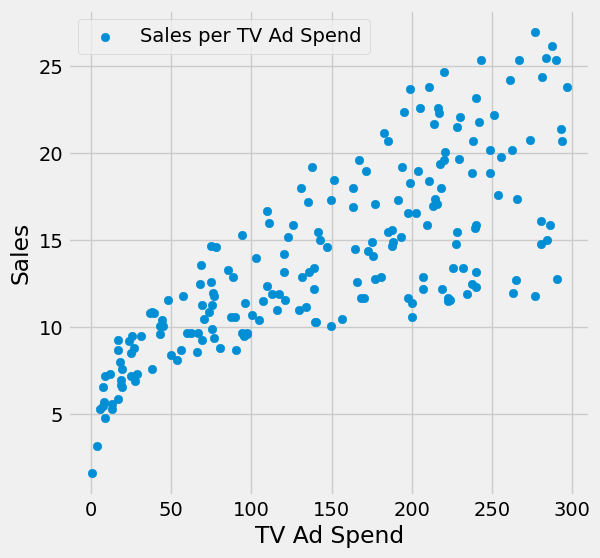

In [ ]:
# simple linear regression

# use TV to Predict Sales

# make scatter showing relationship between TV and sales
plt.figure(figsize=(6, 6))
plt.scatter(df['TV'], df['sales'], label='Sales per TV Ad Spend')
plt.xlabel('TV Ad Spend')
plt.ylabel('Sales')
plt.legend();

In [ ]:
X = df[['TV']]
y = df['sales']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=41)

In [ ]:
X_train.shape, X_test.shape, y_train.shape, y_test.shape

((150, 1), (50, 1), (150,), (50,))

In [ ]:
# make an instance of our model
lr = LinearRegression()
# fit our model
lr.fit(X_train, y_train)

LinearRegression()

In [ ]:
print(f'Training R^2: {round(lr.score(X_train, y_train), 2)}')
print(f'Test R^2: {round(lr.score(X_test, y_test), 2)}')

Training R^2: 0.58
Test R^2: 0.69


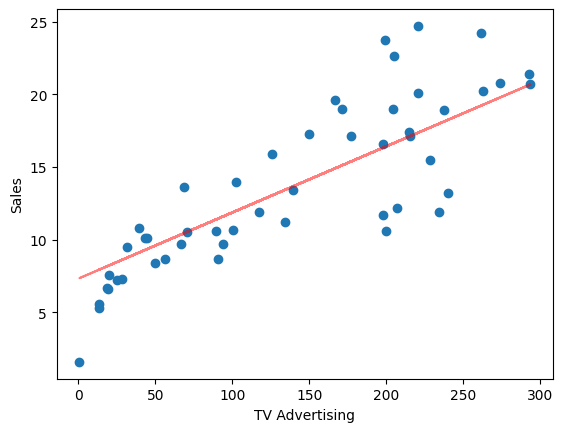

In [ ]:
# plot our test data out and our best fit line

plt.scatter(X_test, y_test)
plt.xlabel('TV Advertising')
plt.ylabel('Sales')
plt.plot(X_test, lr.predict(X_test), color='red', alpha=0.5);

In [ ]:
# if TV Advertising is $175, how much sales will we have according to our model

pred_175 = lr.predict(np.array([175]).reshape(1, -1))

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


In [ ]:
print(f'If TV Advertising is $175, sales will be predicted to be ${round(pred_175[0], 2)}')

If TV Advertising is $175, sales will be predicted to be $15.28


In [ ]:
print(f'Sales = {round(lr.coef_[0], 4)} x TV Advertising + {round(lr.intercept_, 2)}')

Sales = 0.0455 x TV Advertising + 7.33


In [ ]:
lr.coef_[0], lr.intercept_

(np.float64(0.04546219720816552), np.float64(7.327274673567376))

In [ ]:
# TV Advertising is $175

(0.0455 * 175) + lr.intercept_

np.float64(15.289774673567376)

In [ ]:
# increase TV Advertising by $10, how much will that impact sales

0.0455 * 10

0.45499999999999996

In [ ]:
# lets use TV and radio to predict the sales

X = df[['TV', 'radio']]
y = df['sales']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=23)

X_train.shape, X_test.shape, y_train.shape, y_test.shape

((150, 2), (50, 2), (150,), (50,))

In [ ]:
X_train.head(2)

,TV,radio
109,13.1,0.4
190,18.7,12.1


In [ ]:
X_test.head(2)

,TV,radio
96,163.3,31.6
16,195.4,47.7


In [ ]:
# make instance of our model
lr = LinearRegression()

# fit the model
lr.fit(X_train, y_train)

LinearRegression()

In [ ]:
# check for overfitting/underfitting

print(f'Training R2: {round(lr.score(X_train, y_train), 2)}')
print(f'Test R2: {round(lr.score(X_test, y_test),2)}')

Training R2: 0.88
Test R2: 0.92


In [ ]:
# R2 of 0.89 - 89% of the variance in sales can be explained by TV and radio advertising

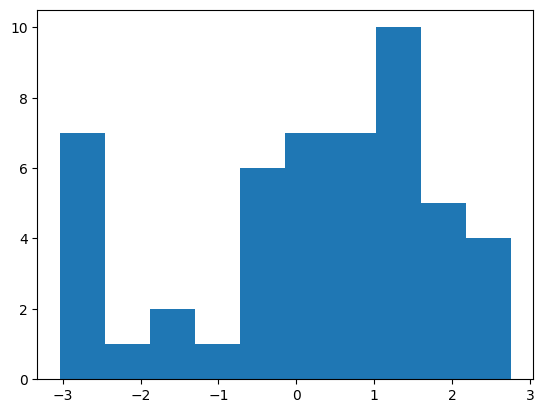

In [ ]:
residuals = y_test - lr.predict(X_test)

plt.hist(residuals, bins=10);

<Axes: xlabel='sales', ylabel='Count'>

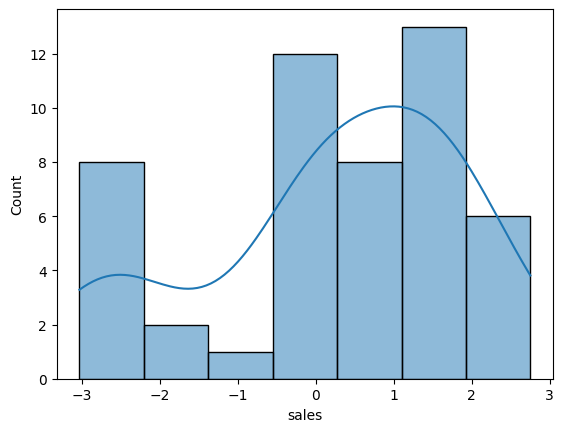

In [ ]:
import seaborn as sns

sns.histplot(residuals, kde=True)

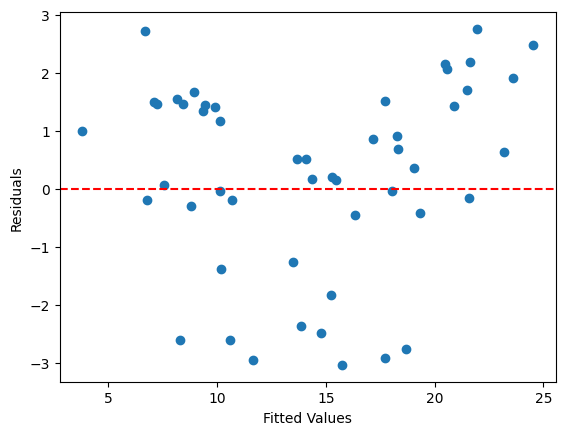

In [ ]:
plt.scatter(lr.predict(X_test), residuals)
plt.axhline(0, color='red', ls='--')
plt.xlabel('Fitted Values')
plt.ylabel('Residuals');

In [ ]:
X_train.columns

Index(['TV', 'radio'], dtype='object')

In [ ]:
print(f'sales = {round(lr.coef_[0], 4)} x TV + {round(lr.coef_[1], 4)} x Radio + {round(lr.intercept_, 2)}')

sales = 0.0459 x TV + 0.1795 x Radio + 3.03


In [ ]:
# 100 in TV Advertising and $50 in Radio Advertising, how much sales will we have

(0.0459 * 100) + (.1795 * 50) + 3.03

16.595000000000002

In [ ]:
pred_df = pd.DataFrame({'TV': [100], 'radio': [50]})
pred_df

,TV,radio
0,100,50


In [ ]:
lr.predict(pred_df)

array([16.60204021])

In [ ]:
# Create 3 additional features with random values (that have no relation with the target variable - sales)
df['Feature_1'] = np.random.uniform(size=200)
df['Feature_2'] = np.random.uniform(size=200)
df['Feature_3'] = np.random.uniform(size=200)

In [ ]:
# make model with all features

X = df.drop(columns=['sales'])
y = df['sales']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42)

In [ ]:
X_train.shape, X_test.shape, y_train.shape, y_test.shape

((150, 6), (50, 6), (150,), (50,))

In [ ]:
# make instance of model
lr = LinearRegression()

# fit our model
lr.fit(X_train, y_train)

LinearRegression()

In [ ]:
# check for overfitting

print(f'Train R2: {round(lr.score(X_train, y_train), 2)}')
print(f'Test R2: {round(lr.score(X_test, y_test), 2)}')

Train R2: 0.9
Test R2: 0.89


In [ ]:
df.corr()['sales']

,sales
TV,0.782224
radio,0.576223
newspaper,0.228299
sales,1.000000
Feature_1,0.105906
Feature_2,-0.069866
Feature_3,0.135704


In [ ]:
# make model with all features

X = df.drop(columns=['sales', 'TV', 'radio', 'newspaper'])
y = df['sales']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42)

In [ ]:
# make instance of model
lr = LinearRegression()

# fit our model
lr.fit(X_train, y_train)

LinearRegression()

In [ ]:
# check for overfitting

print(f'Train R2: {round(lr.score(X_train, y_train), 2)}')
print(f'Test R2: {round(lr.score(X_test, y_test), 2)}')

Train R2: 0.05
Test R2: -0.07


In [ ]:
X_train.head(2)

,Feature_1,Feature_2,Feature_3
115,0.629558,0.792595,0.672703
174,0.657353,0.175222,0.951423


In [ ]:
# data leakage

X = df.drop(columns=['TV', 'radio', 'newspaper'])
y = df['sales']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42)

# make instance of model
lr = LinearRegression()

# fit our model
lr.fit(X_train, y_train)

# check for overfitting

print(f'Train R2: {round(lr.score(X_train, y_train), 2)}')
print(f'Test R2: {round(lr.score(X_test, y_test), 2)}')

Train R2: 1.0
Test R2: 1.0


In [ ]:
pd.Series(lr.coef_, index=X_train.columns).round(2)

,0
sales,1.0
Feature_1,0.0
Feature_2,0.0
Feature_3,0.0


In [ ]:
# make model with all features

X = df.drop(columns=['sales'])
y = df['sales']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42)

In [ ]:
X_train.head(2)

,TV,radio,newspaper,Feature_1,Feature_2,Feature_3
115,78.2,46.8,34.5,0.629558,0.792595,0.672703
174,168.4,7.1,12.8,0.657353,0.175222,0.951423


In [ ]:
from sklearn.linear_model import Lasso

lasso = Lasso()

lasso.fit(X_train, y_train)

Lasso()

In [ ]:
pd.Series(lasso.coef_, index=X_train.columns).round(4)

,0
TV,0.0453
radio,0.1876
newspaper,0.0013
Feature_1,0.0000
Feature_2,-0.0000
Feature_3,-0.0000


In [ ]:
lasso.score(X_train, y_train)

0.8964500242832878

In [ ]:
lasso.score(X_test, y_test)

0.8951947205229301